# Klasifikacija vesti (fake / real)


## Biblioteke


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Preuzimanje dataseta


In [53]:
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p data --unzip

'kaggle' is not recognized as an internal or external command,
operable program or batch file.


## Ucitavanje podataka


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Download necessary NLTK data
nltk.download('stopwords')

# LOAD DATA

fake = pd.read_csv('./data/Fake.csv')
true = pd.read_csv('./data/True.csv')

fake['label'] = 1
true['label'] = 0

df = pd.concat([fake, true], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

df = df[['text', 'label']]

# PREPROCESSING FUNCTION
ps = PorterStemmer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

print("Cleaning text... (this may take a few minutes)")
df['text'] = df['text'].apply(clean_text)
print("Cleaning complete!")

# SPLIT DATA
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# VECTORIZATION (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# MODEL TRAINING & EVALUATION

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, predictions)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))
    results[name] = acc

# FINAL COMPARISON
print("\n" + "="*30)
print("FINAL MODEL COMPARISON")
print("="*30)
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

[nltk_data] Downloading package stopwords to /home/uno/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning text... (this may take a few minutes)
Cleaning complete!

--- Training Logistic Regression ---
Accuracy: 0.9846
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4270
           1       0.99      0.98      0.99      4710

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


--- Training KNN ---
Accuracy: 0.7399
              precision    recall  f1-score   support

           0       0.91      0.50      0.65      4270
           1       0.68      0.96      0.79      4710

    accuracy                           0.74      8980
   macro avg       0.80      0.73      0.72      8980
weighted avg       0.79      0.74      0.72      8980


--- Training Linear SVM ---
Accuracy: 0.9931
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4270
           1       0.99      0.

## Pregled podataka


In [55]:
df.info()

print()
print(df["label"].value_counts())
print()
print("duplikata:", df.duplicated(subset="text").sum())
print("praznih  :", df["text"].str.strip().eq("").sum())
print()
print(df["subject"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

label
1    23481
0    21417
Name: count, dtype: int64

duplikata: 6252
praznih  : 631

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


## Uklanjanje laznih signala iz izvora


In [56]:
import re

ima_reuters = df["text"].str.contains("Reuters", case=False, na=False)

datelina = re.compile(r"^\s*[A-Za-z .,'/-]{0,60}\(Reuters\)\s*-\s*")
pocinje = df["text"].str.match(datelina)

prave = df["label"] == 0
lazne = df["label"] == 1

print("sadrzi 'Reuters'   prave:", round(ima_reuters[prave].mean(), 4),
      " lazne:", round(ima_reuters[lazne].mean(), 4))
print("pocinje datelinom  prave:", round(pocinje[prave].mean(), 4),
      " lazne:", round(pocinje[lazne].mean(), 4))

pravilo = (ima_reuters == False).astype(int)

print()
print("tacnost pravila 'nema Reuters -> lazna':",
      round((pravilo == df["label"]).mean(), 4))


sadrzi 'Reuters'   prave: 0.9982  lazne: 0.0137
pocinje datelinom  prave: 0.9847  lazne: 0.0

tacnost pravila 'nema Reuters -> lazna': 0.992


### Funkcija za ciscenje


In [57]:
def ocisti(tekst):
    tekst = str(tekst)

    tekst = re.sub(r"^\s*[A-Za-z .,'/-]{0,60}\(Reuters\)\s*-\s*", "", tekst)

    tekst = re.sub(r"\(reuters\)", " ", tekst, flags=re.IGNORECASE)
    tekst = re.sub(r"\breuters\b", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"(featured image via|image via|featured image|getty images|pic\.twitter\.com|screen capture|screenshot via|photo by)", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"(https?://\S+|www\.\S+|\b\S+\.com\b)", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"@\w+", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"\b(monday|tuesday|wednesday|thursday|friday|saturday|sunday)\b", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"\b(january|february|march|april|may|june|july|august|september|october|november|december)\b", " ", tekst, flags=re.IGNORECASE)

    tekst = re.sub(r"\s+", " ", tekst)
    tekst = tekst.strip()

    return tekst


df["text_ok"] = df["text"].apply(ocisti)

koliko = df["text_ok"].str.contains("reuters", case=False).sum()
print("Jos uvek ima rec 'Reuters' u", koliko, "clanaka")
print("Prosecna duzina pre  :", round(df["text"].str.len().mean()))
print("Prosecna duzina posle:", round(df["text_ok"].str.len().mean()))
print()

prave = df[df["label"] == 0]
print("PRE  :", prave["text"].iloc[0][:100])
print("POSLE:", prave["text_ok"].iloc[0][:100])


Jos uvek ima rec 'Reuters' u 18 clanaka
Prosecna duzina pre  : 2469
Prosecna duzina posle: 2410

PRE  : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from th
POSLE: U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Cou


### Prazni tekstovi


In [58]:
df["duzina"] = df["text_ok"].str.len()

prazni = df[df["duzina"] < 40]
puni = df[df["duzina"] >= 40]

print("praznih clanaka:", len(prazni))
print("  lazne:", len(prazni[prazni["label"] == 1]))
print("  prave:", len(prazni[prazni["label"] == 0]))

df = puni
df = df.reset_index(drop=True)

print()
print("ostalo:", len(df))
print(df["label"].value_counts())


praznih clanaka: 820
  lazne: 819
  prave: 1

ostalo: 44078
label
1    22662
0    21416
Name: count, dtype: int64


## Klasicni modeli (bazne linije)


### Priprema teksta


In [59]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)

ps = PorterStemmer()
stop_words = set(stopwords.words("english"))


def clean_text(text):
    text = re.sub("[^a-zA-Z]", " ", str(text))
    words = text.lower().split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)


df["text_clean"] = df["text_ok"].apply(clean_text)

df[["text_ok", "text_clean", "label"]].head(3)


,text_ok,text_clean,label
0,"21st Century Wire says Ben Stein, reputable pr...",st centuri wire say ben stein reput professor ...,1
1,U.S. President Donald Trump removed his chief ...,u presid donald trump remov chief strategist s...,0
2,Puerto Rico Governor Ricardo Rossello said on ...,puerto rico governor ricardo rossello said exp...,0


### Podela i TF-IDF vektorizacija


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Xk = df["text_clean"]
yk = df["label"]

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    Xk, yk, test_size=0.2, stratify=yk, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
Xk_train_tfidf = tfidf.fit_transform(Xk_train)
Xk_test_tfidf = tfidf.transform(Xk_test)

print(Xk_train_tfidf.shape, Xk_test_tfidf.shape)
print()
print(yk_test.value_counts())


(35262, 5000) (8816, 5000)

label
1    4533
0    4283
Name: count, dtype: int64


### Treniranje i evaluacija


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

modeli_klasicni = {
    "Logisticka regresija": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Linearni SVM": LinearSVC(),
}

rezultati_klasicni = {}
predikcije_klasicne = {}

for naziv, model in modeli_klasicni.items():
    model.fit(Xk_train_tfidf, yk_train)
    pred = model.predict(Xk_test_tfidf)

    rezultati_klasicni[naziv] = accuracy_score(yk_test, pred)
    predikcije_klasicne[naziv] = pred

    print(naziv)
    print(classification_report(yk_test, pred,
                                target_names=["prava", "lazna"], digits=4))


Logisticka regresija
              precision    recall  f1-score   support

       prava     0.9738    0.9792    0.9765      4283
       lazna     0.9803    0.9751    0.9777      4533

    accuracy                         0.9771      8816
   macro avg     0.9770    0.9771    0.9771      8816
weighted avg     0.9771    0.9771    0.9771      8816

KNN (k=5)
              precision    recall  f1-score   support

       prava     0.8295    0.9279    0.8759      4283
       lazna     0.9232    0.8198    0.8684      4533

    accuracy                         0.8723      8816
   macro avg     0.8764    0.8738    0.8722      8816
weighted avg     0.8777    0.8723    0.8721      8816

Linearni SVM
              precision    recall  f1-score   support

       prava     0.9850    0.9832    0.9841      4283
       lazna     0.9841    0.9859    0.9850      4533

    accuracy                         0.9846      8816
   macro avg     0.9846    0.9845    0.9846      8816
weighted avg     0.9846    0.9

### Kernelizovani SVM


In [62]:
from sklearn.svm import SVC

BROJ_PRIMERA = 8000

X_manji = Xk_train_tfidf[:BROJ_PRIMERA]
y_manji = yk_train.iloc[:BROJ_PRIMERA]

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(X_manji, y_manji)

pred_rbf = svm_rbf.predict(Xk_test_tfidf)
tacnost_rbf = accuracy_score(yk_test, pred_rbf)

svm_lin_manji = LinearSVC()
svm_lin_manji.fit(X_manji, y_manji)
pred_lin = svm_lin_manji.predict(Xk_test_tfidf)

rezultati_klasicni["Kernelizovani SVM"] = tacnost_rbf
predikcije_klasicne["Kernelizovani SVM"] = pred_rbf

print("RBF SVM     :", round(tacnost_rbf, 4))
print("linearni SVM:", round(accuracy_score(yk_test, pred_lin), 4))
print("potpornih vektora:", svm_rbf.n_support_.sum(), "od", BROJ_PRIMERA)
print()
print(classification_report(yk_test, pred_rbf,
                            target_names=["prava", "lazna"], digits=4))


RBF SVM     : 0.9707
linearni SVM: 0.9723
potpornih vektora: 3842 od 8000

              precision    recall  f1-score   support

       prava     0.9649    0.9753    0.9700      4283
       lazna     0.9764    0.9665    0.9714      4533

    accuracy                         0.9707      8816
   macro avg     0.9706    0.9709    0.9707      8816
weighted avg     0.9708    0.9707    0.9707      8816



### Poredjenje baznih linija


                      accuracy  precision  recall      f1
model                                                    
Linearni SVM            0.9846     0.9841  0.9859  0.9850
Logisticka regresija    0.9771     0.9803  0.9751  0.9777
Kernelizovani SVM       0.9707     0.9764  0.9665  0.9714
KNN (k=5)               0.8723     0.9232  0.8198  0.8684


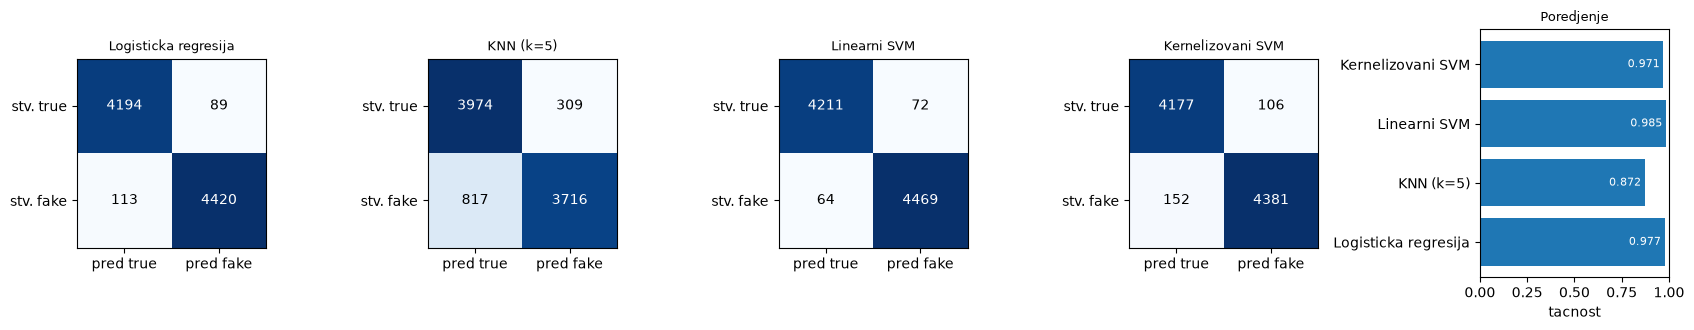

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

redovi = []
for naziv, pred in predikcije_klasicne.items():
    prec, rec, f1, _ = precision_recall_fscore_support(
        yk_test, pred, average="binary", zero_division=0)
    redovi.append({"model": naziv, "accuracy": rezultati_klasicni[naziv],
                   "precision": prec, "recall": rec, "f1": f1})

tabela_klasicni = pd.DataFrame(redovi).set_index("model").round(4)
print(tabela_klasicni.sort_values("f1", ascending=False))

fig, axes = plt.subplots(1, len(predikcije_klasicne) + 1,
                         figsize=(3.4 * (len(predikcije_klasicne) + 1), 3.4))

for ax, (naziv, pred) in zip(axes, predikcije_klasicne.items()):
    cm = confusion_matrix(yk_test, pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(naziv, fontsize=9)
    ax.set_xticks([0, 1], ["pred true", "pred fake"])
    ax.set_yticks([0, 1], ["stv. true", "stv. fake"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

axes[-1].barh(list(rezultati_klasicni.keys()), list(rezultati_klasicni.values()))
axes[-1].set_xlim(0, 1)
axes[-1].set_xlabel("tacnost")
axes[-1].set_title("Poredjenje", fontsize=9)
for i, v in enumerate(rezultati_klasicni.values()):
    axes[-1].text(v - 0.02, i, f"{v:.3f}", va="center", ha="right",
                  color="white", fontsize=8)

plt.tight_layout()
plt.show()


## Tokenizacija i podela na skupove


In [64]:
!pip install scikit-learn

You should consider upgrading via the 'C:\Users\bogda\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(df.text_ok, df.label, stratify = df.label, random_state=42)

tok = Tokenizer(num_words = 3000, oov_token = "<OOV>")


tok.fit_on_texts(X_train)

Xtre = pad_sequences(tok.texts_to_sequences(X_train), 300, truncating="post")
Xpre = pad_sequences(tok.texts_to_sequences(X_test), 300, truncating="post")


## CNN model


In [66]:

from tensorflow.keras import layers, models

cnn = models.Sequential([
    layers.Embedding(3000, 128, input_length=300),
    layers.Conv1D(128, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

c:\Users\bogda\miniconda3\envs\ml\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## LSTM model


In [67]:
lstm = models.Sequential([
    layers.Embedding(3000, 128, input_length=300),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## Treniranje


In [68]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
hist = cnn.fit(Xtre, y_train, validation_split=0.1, epochs=10, batch_size=64, callbacks=[es])

Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.9351 - loss: 0.1534 - val_accuracy: 0.9843 - val_loss: 0.0414
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 161s 347ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9921 - val_loss: 0.0256
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 90s 195ms/step - accuracy: 0.9941 - loss: 0.0175 - val_accuracy: 0.9909 - val_loss: 0.0239
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 117s 251ms/step - accuracy: 0.9960 - loss: 0.0128 - val_accuracy: 0.9927 - val_loss: 0.0244
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 77s 166ms/step - accuracy: 0.9964 - loss: 0.0112 - val_accuracy: 0.9927 - val_loss: 0.0250


## Hibridni model: 1D CNN + LSTM


In [69]:
hibrid = models.Sequential([
    layers.Input(shape=(300,)),
    layers.Embedding(3000, 128),
    layers.Conv1D(128, 5, activation="relu"),
    layers.MaxPooling1D(4),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

hibrid.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hibrid.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 300, 128)       │       384,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,521 (1.97 MB)

 Trainable params: 515,521 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

### Treniranje hibrida


In [42]:
es_hibrid = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

hist_hibrid = hibrid.fit(Xtre, y_train, validation_split=0.1,
                         epochs=10, batch_size=64, callbacks=[es_hibrid])


Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 228s 473ms/step - accuracy: 0.9087 - loss: 0.2251 - val_accuracy: 0.9746 - val_loss: 0.0839
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 98s 212ms/step - accuracy: 0.9850 - loss: 0.0552 - val_accuracy: 0.9849 - val_loss: 0.0484
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 205s 441ms/step - accuracy: 0.9923 - loss: 0.0284 - val_accuracy: 0.9906 - val_loss: 0.0317
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - accuracy: 0.9920 - loss: 0.0265 - val_accuracy: 0.9906 - val_loss: 0.0301
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 146s 313ms/step - accuracy: 0.9961 - loss: 0.0147 - val_accuracy: 0.9936 - val_loss: 0.0279
Epoch 6/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 148s 318ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9891 - val_loss: 0.0318
Epoch 7/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 138s 295ms/step - accuracy: 0.9972 - loss: 0.0099 - val_accuracy: 0.9918 - val_loss: 0.0353


## Dotreniranje transformera


In [43]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256, padding="max_length")

args = TrainingArguments(
    output_dir="out", num_train_epochs=2, learning_rate=2e-5,
    per_device_train_batch_size=32, eval_strategy="epoch")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2027.94it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Testovi i rezultati


### 2. Pomocne funkcije za evaluaciju


In [44]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

rezultati = {}
verovatnoce = {}
istinite = {}


def oceni(naziv, y_true, y_prob, prag=0.5, ispis=True):
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= prag).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    rezultati[naziv] = {"accuracy": acc, "precision": prec,
                        "recall": rec, "f1": f1, "roc_auc": auc}
    verovatnoce[naziv] = y_prob
    istinite[naziv] = y_true

    if ispis:
        print(naziv)
        print(classification_report(y_true, y_pred,
                                    target_names=["prava", "lazna"],
                                    digits=4, zero_division=0))
    return rezultati[naziv]


def matrica_konfuzije(ax, y_true, y_pred, naslov):
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(naslov, fontsize=9)
    ax.set_xticks([0, 1], ["pred prava", "pred lazna"])
    ax.set_yticks([0, 1], ["prava", "lazna"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    return cm


print("test skup:", len(y_test))
print(pd.Series(np.asarray(y_test)).value_counts())


test skup: 11020
1    5666
0    5354
Name: count, dtype: int64


### 3. Treniranje LSTM-a


In [45]:
from tensorflow.keras.callbacks import EarlyStopping

es_lstm = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
hist_lstm = lstm.fit(Xtre, y_train, validation_split=0.1,
                     epochs=10, batch_size=64, callbacks=[es_lstm])


Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 449s 946ms/step - accuracy: 0.9145 - loss: 0.2224 - val_accuracy: 0.9782 - val_loss: 0.0703
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 391s 842ms/step - accuracy: 0.9449 - loss: 0.1532 - val_accuracy: 0.9356 - val_loss: 0.1651
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 455s 979ms/step - accuracy: 0.9667 - loss: 0.1066 - val_accuracy: 0.9831 - val_loss: 0.0637
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 436s 939ms/step - accuracy: 0.9878 - loss: 0.0453 - val_accuracy: 0.9873 - val_loss: 0.0438
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 366s 788ms/step - accuracy: 0.9701 - loss: 0.0879 - val_accuracy: 0.9761 - val_loss: 0.0683
Epoch 6/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 461s 990ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9837 - val_loss: 0.0481


### 4. Rezultati na test skupu


In [46]:
y_true = np.asarray(y_test)

oceni("CNN", y_true, cnn.predict(Xpre, verbose=0))
oceni("BiLSTM", y_true, lstm.predict(Xpre, verbose=0))
oceni("CNN + LSTM (hibrid)", y_true, hibrid.predict(Xpre, verbose=0))

pd.DataFrame(rezultati).T.round(4)


CNN
              precision    recall  f1-score   support

       prava     0.9914    0.9938    0.9926      5354
       lazna     0.9942    0.9919    0.9930      5666

    accuracy                         0.9928     11020
   macro avg     0.9928    0.9929    0.9928     11020
weighted avg     0.9928    0.9928    0.9928     11020

BiLSTM
              precision    recall  f1-score   support

       prava     0.9878    0.9815    0.9846      5354
       lazna     0.9826    0.9885    0.9856      5666

    accuracy                         0.9851     11020
   macro avg     0.9852    0.9850    0.9851     11020
weighted avg     0.9851    0.9851    0.9851     11020

CNN + LSTM (hibrid)
              precision    recall  f1-score   support

       prava     0.9947    0.9901    0.9924      5354
       lazna     0.9907    0.9951    0.9929      5666

    accuracy                         0.9926     11020
   macro avg     0.9927    0.9926    0.9926     11020
weighted avg     0.9927    0.9926    0.9926

,accuracy,precision,recall,f1,roc_auc
CNN,0.9928,0.9942,0.9919,0.9930,0.9996
BiLSTM,0.9851,0.9826,0.9885,0.9856,0.9978
CNN + LSTM (hibrid),0.9926,0.9907,0.9951,0.9929,0.9993


### 5. Donja granica i osnovni TF-IDF


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
oceni("Dummy (vecinska klasa)", y_true, dummy.predict_proba(X_test)[:, 1])

tfidf_osnovni = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
tfidf_osnovni.fit(X_train, y_train)
oceni("TF-IDF+LogReg (osnovni)", y_true, tfidf_osnovni.predict_proba(X_test)[:, 1])

pd.DataFrame(rezultati).T.round(4)


Dummy (vecinska klasa)
              precision    recall  f1-score   support

       prava     0.0000    0.0000    0.0000      5354
       lazna     0.5142    1.0000    0.6791      5666

    accuracy                         0.5142     11020
   macro avg     0.2571    0.5000    0.3396     11020
weighted avg     0.2644    0.5142    0.3492     11020

TF-IDF+LogReg (osnovni)
              precision    recall  f1-score   support

       prava     0.9784    0.9817    0.9800      5354
       lazna     0.9826    0.9795    0.9811      5666

    accuracy                         0.9806     11020
   macro avg     0.9805    0.9806    0.9806     11020
weighted avg     0.9806    0.9806    0.9806     11020



,accuracy,precision,recall,f1,roc_auc
CNN,0.9928,0.9942,0.9919,0.9930,0.9996
BiLSTM,0.9851,0.9826,0.9885,0.9856,0.9978
CNN + LSTM (hibrid),0.9926,0.9907,0.9951,0.9929,0.9993
Dummy (vecinska klasa),0.5142,0.5142,1.0000,0.6791,0.5000
TF-IDF+LogReg (osnovni),0.9806,0.9826,0.9795,0.9811,0.9976


### 6. TF-IDF sa bigramima


In [48]:
from sklearn.model_selection import train_test_split

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    df.text_ok, df.label, stratify=df.label, random_state=42)

tfidf_text = make_pipeline(
    TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000))
tfidf_text.fit(Xt_train, yt_train)

oceni("TF-IDF+LogReg (bigrami)", np.asarray(yt_test),
      tfidf_text.predict_proba(Xt_test)[:, 1])

pd.DataFrame(rezultati).T.round(4).sort_values("f1", ascending=False)


TF-IDF+LogReg (bigrami)
              precision    recall  f1-score   support

       prava     0.9821    0.9839    0.9830      5354
       lazna     0.9848    0.9831    0.9839      5666

    accuracy                         0.9835     11020
   macro avg     0.9834    0.9835    0.9835     11020
weighted avg     0.9835    0.9835    0.9835     11020



,accuracy,precision,recall,f1,roc_auc
CNN,0.9928,0.9942,0.9919,0.9930,0.9996
CNN + LSTM (hibrid),0.9926,0.9907,0.9951,0.9929,0.9993
BiLSTM,0.9851,0.9826,0.9885,0.9856,0.9978
TF-IDF+LogReg (bigrami),0.9835,0.9848,0.9831,0.9839,0.9981
TF-IDF+LogReg (osnovni),0.9806,0.9826,0.9795,0.9811,0.9976
Dummy (vecinska klasa),0.5142,0.5142,1.0000,0.6791,0.5000


### 7. Matrice konfuzije i ROC krive


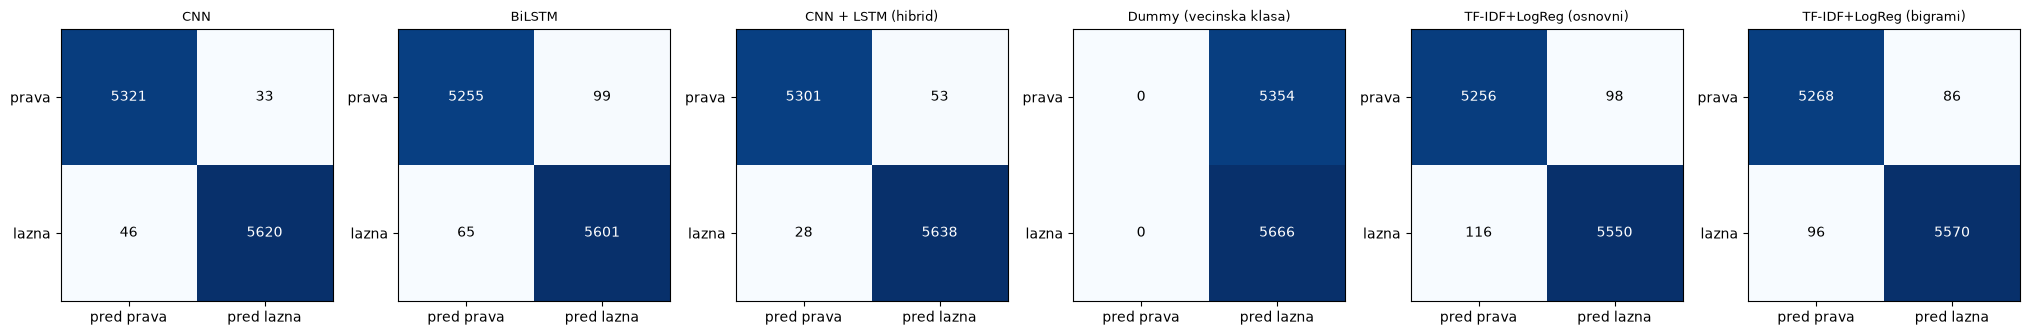

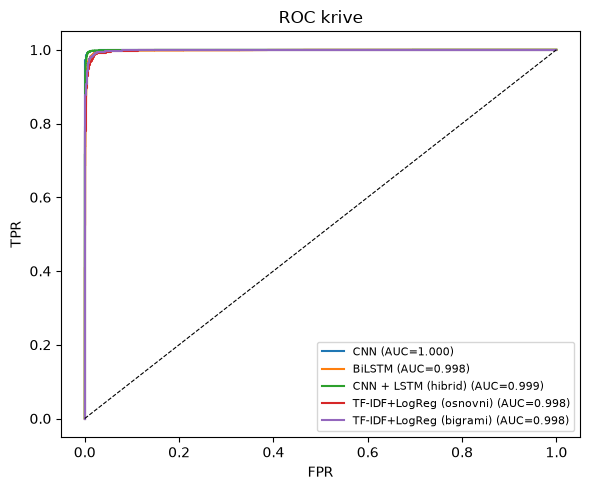

In [49]:
nazivi = list(verovatnoce.keys())

fig, axes = plt.subplots(1, len(nazivi), figsize=(3.4 * len(nazivi), 3.4))
axes = np.atleast_1d(axes)
for ax, naziv in zip(axes, nazivi):
    matrica_konfuzije(ax, istinite[naziv],
                      (verovatnoce[naziv] >= 0.5).astype(int), naziv)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for naziv in nazivi:
    if len(np.unique(verovatnoce[naziv])) < 2:
        continue
    fpr, tpr, _ = roc_curve(istinite[naziv], verovatnoce[naziv])
    plt.plot(fpr, tpr, label=f"{naziv} (AUC={rezultati[naziv]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC krive")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 8. Krive ucenja (provera overfita)


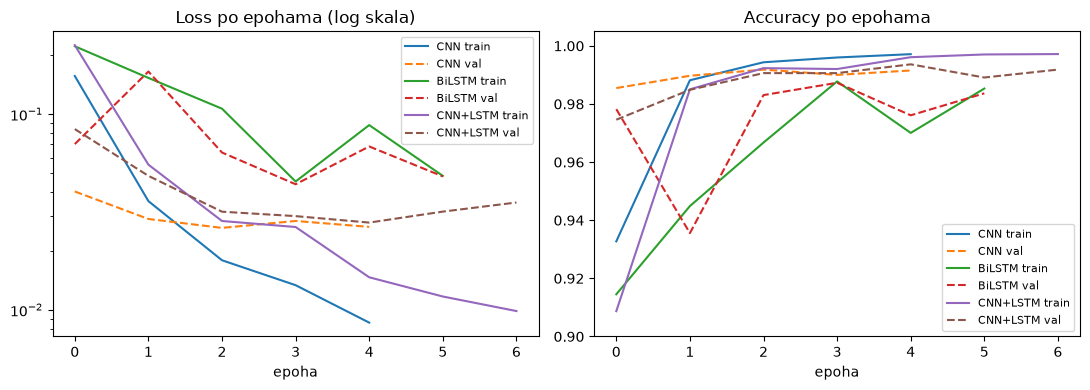

CNN | najbolja epoha: 3 od 5 | train: 0.0179 | val: 0.0262
BiLSTM | najbolja epoha: 4 od 6 | train: 0.0453 | val: 0.0438
CNN+LSTM | najbolja epoha: 5 od 7 | train: 0.0147 | val: 0.0279


In [50]:
istorije = {"CNN": hist, "BiLSTM": hist_lstm, "CNN+LSTM": hist_hibrid}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for naziv, h in istorije.items():
    axes[0].plot(h.history["loss"], label=naziv + " train")
    axes[0].plot(h.history["val_loss"], "--", label=naziv + " val")
    axes[1].plot(h.history["accuracy"], label=naziv + " train")
    axes[1].plot(h.history["val_accuracy"], "--", label=naziv + " val")

axes[0].set_yscale("log")
axes[0].set_title("Loss po epohama (log skala)")
axes[0].set_xlabel("epoha")
axes[0].legend(fontsize=8)
axes[1].set_ylim(0.9, 1.005)
axes[1].set_title("Accuracy po epohama")
axes[1].set_xlabel("epoha")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for naziv, h in istorije.items():
    vl = h.history["val_loss"]
    tl = h.history["loss"]
    naj = int(np.argmin(vl))

    print(naziv,
          "| najbolja epoha:", naj + 1, "od", len(vl),
          "| train:", round(tl[naj], 4),
          "| val:", round(vl[naj], 4))


### 9. test protiv test_ok


In [51]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

varijante = {"originalni text": "text", "ocisceni text_ok": "text_ok"}
poredjenje = []
modeli_cena = {}

for opis, kol in varijante.items():
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
        df[kol], df.label, stratify=df.label, random_state=42)

    vek = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
    Xa_tr_v = vek.fit_transform(Xa_tr)
    Xa_te_v = vek.transform(Xa_te)

    red = {"varijanta": opis}
    for ime_m, m in (("LogReg", LogisticRegression(max_iter=1000)),
                     ("LinearSVC", LinearSVC())):
        m.fit(Xa_tr_v, ya_tr)
        red[ime_m] = accuracy_score(ya_te, m.predict(Xa_te_v))
        modeli_cena[(opis, ime_m)] = (m, vek)
    poredjenje.append(red)

tabela_artefakti = pd.DataFrame(poredjenje).set_index("varijanta").round(4)

print(tabela_artefakti)
print()
print("razlika:")
print((tabela_artefakti - tabela_artefakti.loc["originalni text"]).round(4))


                  LogReg  LinearSVC
varijanta                          
originalni text   0.9895     0.9966
ocisceni text_ok  0.9835     0.9934

razlika:
                  LogReg  LinearSVC
varijanta                          
originalni text    0.000     0.0000
ocisceni text_ok  -0.006    -0.0032
